In [46]:
# load the module
%load_ext autoreload
%autoreload 2

import sys 
import os
sys.path.append("../Qtensor")
sys.path.append("../Qtensor/qtree_git")
sys.path.append("../Qtensor/qtree_git/qtree")
sys.path.append("../classical_benchmarks")
sys.path.append("../Experiments/SetCover")
sys.path.append("../../..")
sys.path.append("..")

import json
import copy
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import Generating_Problems as Generator
from gurobi_optimods.qubo import solve_qubo
import qubovert as qv
from qubovert.problems import SetCover as qv_SetCover
import matplotlib

matplotlib.rcParams.update(matplotlib.rcParamsDefault)
 
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin/' # for latex, you might need to change this


#print(os.environ['PATH'])# = os.environ['PATH'] + 'c:/Library/TeX/texbin/' # for latex, you might need to change this
label_size = 8
# plt.style.use('fivethirtyeight')
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r'\usepackage{dsfont}\usepackage{amsmath}\usepackage{physics}')
#matplotlib.rcParams['text.latex.preamble']=[r'/usepackage{dsfont}/usepackage{amsmath}/usepackage{physics}']
 
pr ={"axes.labelsize": 8,               # LaTeX default is 10pt font.
     'axes.titlesize': 8,               
    "font.size": 8,
    "legend.fontsize": 8,               # Make the legend/label fonts
    "xtick.labelsize": 8,               # a little smaller
    "ytick.labelsize": 8,
    'figure.figsize': (1 * 3.35, 1.5* 9 * 3.35 / 16), #2.0476
    "errorbar.capsize": 1.5,
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots
    "font.sans-serif": [],    
    }
for k, v in pr.items():
    matplotlib.rcParams[k] = v
   
matplotlib.rcParams["font.family"] = "serif"
# mpl.rcParams["font.serif"] = ["STIX"]
matplotlib.rcParams["mathtext.fontset"] = "stix"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
ns = range(100)
run = 2

In [25]:
def gurobi_solver(set, subsets):
    problem = qv_SetCover(set, subsets)
    Q = problem.to_qubo()
    size = problem.num_binary_variables
    matrix = np.zeros((size, size))
    for key, value in Q.items():
        if len(key)==0:
            pass
        elif len(key) == 1:
            matrix[key[0], key[0]] = value
        else:
            matrix[key[0], key[1]] = value

    result = solve_qubo(matrix)
    set_size = 0
    for i in range(len(subsets)):
        set_size += result.solution[i]
        
    return set_size

In [75]:
set_sizes = []
shrinking_sizes = []
greedy_sizes = []
num_examples = 0

for n in ns: 
    with open(f'../data/results_node{n}_run_{run}.json') as f:
        data = json.load(f)
    
    for dic in data:
        set = dic["Set"]
        subsets = dic["Subsets"]
        shrinking_solution = dic["shrinking_solution"]
        problem = Generator.SetCover(set, subsets, A=2, B=1)   
        valid, rest_size = problem.solution_check(shrinking_solution)
        print(valid)
        
        #if valid:
        optimal_size = gurobi_solver(set, subsets)
        size = len(dic["Set"])
        size_shrinking = dic["shrinking_size"]
        size_greedy = dic['greedy_size']

        #corrected_shrinking_size = size_shrinking + rest_size

        set_sizes.append(size)
        #for original size:
        shrinking_sizes.append(size_shrinking/optimal_size)

        #for corrected size:
        #shrinking_sizes.append(corrected_shrinking_size/optimal_size)

        greedy_sizes.append(size_greedy/optimal_size)
        num_examples +=1

True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -63.0
New QUBO solution found with objective -69.0
New QUBO solution found with objective -73.0
New QUBO solution found with objective -74.0
New QUBO solution found with objective -75.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -62.0
New QUBO solution found with objective -68.0
New QUBO solution found with objective -74.0
New QUBO solution found with objective -75.0
New QUBO solution found with objective -76.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -41.0
New QUBO solution found with objective -48.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -43.0
New QUBO solution found with objective -44.0
New QUBO solution found with objective -46.0
New QUBO solution found with objective -47.0
True
New QUBO solution found with objective 0.0
New QUBO solution found with objective -

In [76]:
num_examples

10000

In [82]:
size_to_shrinking_values = defaultdict(list)
size_to_greedy_values = defaultdict(list)

# Fill the dictionary with values corresponding to each size
for size, shrinking_value, greedy_value in zip(set_sizes, shrinking_sizes, greedy_sizes):
    size_to_shrinking_values[size].append(shrinking_value)
    size_to_greedy_values[size].append(greedy_value)


# Initialize the lists for unique sizes and mean values
unique_sizes = []
mean_values_shrinking = []
std_values_shrinking = []
mean_values_greedy = []
std_values_greedy = []

# Compute mean values for each unique size
for size in size_to_shrinking_values:
    print(size, len(size_to_shrinking_values[size]))
    unique_sizes.append(size)
    mean_values_shrinking.append(np.mean(size_to_shrinking_values[size]))
    std_values_shrinking.append(np.std(size_to_shrinking_values[size]))

# Compute mean values for each unique size
for size in size_to_greedy_values:
    mean_values_greedy.append(np.mean(size_to_greedy_values[size]))
    std_values_greedy.append(np.std(size_to_greedy_values[size]))

# for size in unique_sizes:
#     print("\nsize")
#     print('shrinking', len(size_to_shrinking_values[size]))
#     print('greedy', len(size_to_greedy_values[size]))



list_to_sort_by = unique_sizes
zipped_lists = zip(list_to_sort_by, unique_sizes, mean_values_shrinking, std_values_shrinking, mean_values_greedy, std_values_greedy)
sorted_zipped_lists = sorted(zipped_lists, key = lambda x: x[0])
_, sorted_unique_sizes, sorted_mean_values_shrinking, sorted_std_values_shrinking, sorted_mean_values_greedy, sorted_std_values_greedy = zip(*sorted_zipped_lists)
sorted_unique_sizes = list(sorted_unique_sizes)
sorted_mean_values_shrinking = list(sorted_mean_values_shrinking)
sorted_mean_values_greedy = list(sorted_mean_values_greedy)
sorted_std_values_shrinking = list(sorted_std_values_shrinking)
sorted_std_values_greedy = list(sorted_std_values_greedy)


49 181
50 134
31 251
30 257
18 200
53 64
26 258
39 268
40 277
47 202
36 267
34 260
45 220
46 203
38 288
19 244
8 89
48 174
6 42
27 264
24 262
15 204
44 245
22 216
51 108
21 265
25 250
54 38
33 258
17 227
11 108
23 245
43 243
20 274
41 260
35 277
9 82
4 13
42 255
29 263
7 62
32 254
12 119
14 164
28 263
13 141
16 198
52 90
10 112
37 251
5 42
59 5
56 7
57 13
3 7
2 1
55 26
58 6
60 2
61 1


In [83]:
sorted_mean_values_greedy.pop()
sorted_mean_values_greedy.pop()

sorted_mean_values_shrinking.pop()
sorted_mean_values_shrinking.pop()

sorted_std_values_greedy.pop()
sorted_std_values_greedy.pop()

sorted_std_values_shrinking.pop()
sorted_std_values_shrinking.pop()

sorted_unique_sizes.pop()
sorted_unique_sizes.pop()

60

### All valid solutions

[1.0, 1.0, 1.0, 1.2306485092933752, 1.2631165128476989, 1.3919398803720286, 1.3704528719595195, 1.4477228927977932, 1.5253173785864675, 1.6367163241685254, 1.6085275328025292, 1.5095445986882723, 1.4876573185989423, 1.586404289657087, 1.6376551064245994, 1.575971191027798, 1.6583641934327051, 1.7189848780693993, 1.671386017556401, 1.6956234517372446, 1.6561703345126628, 1.7074353523993817, 1.7331439036598146, 1.7915893550220698, 1.786626015731787, 1.789685415349397, 1.7511379041312312, 1.8850038379165532, 1.9059919199586157, 1.84819778012259, 1.8397936294923214, 1.8835713827536371, 1.903043186983367, 1.8659702159357388, 1.8427740125414969, 1.840697300275567, 1.8625580284362067, 1.9186676514081598, 1.8703361817865936, 1.8673058167356187, 1.8755414357522349, 1.8561712412986082, 1.863632342086551, 1.8853342362510868, 1.9241651007495961, 1.915503019224268, 1.9366195981771244, 1.9521815382092003, 1.8481129702514778, 1.9316255492603398, 1.8310111571402607, 1.779448415980427, 1.75125776418250

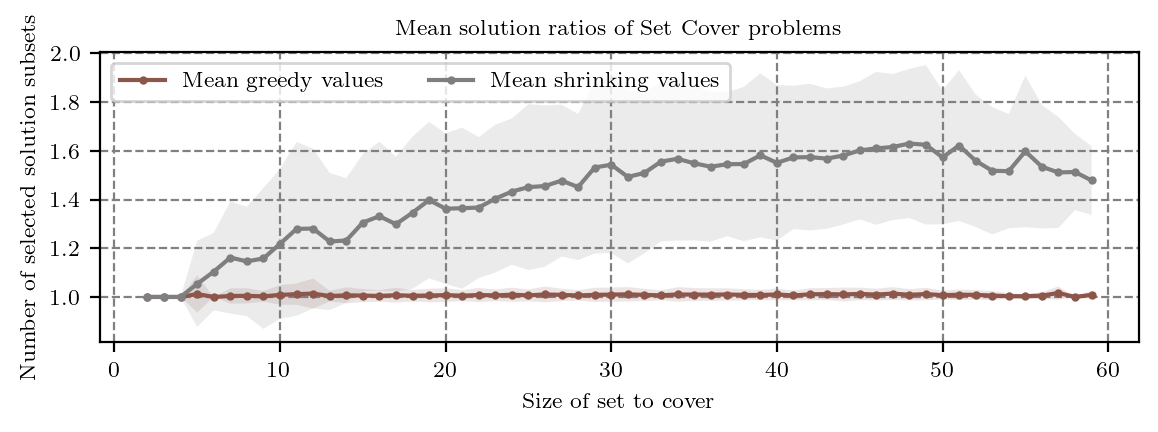

In [85]:
colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:pink', 'tab:brown', 'tab:grey', 'tab:olive', 'tab:cyan']
fig, ax = plt.subplots(1, 1, dpi=200, figsize=(2 * 3.35, 1.* 9 * 3.35 / 16))

upper_bound = [i + j for i, j in zip(sorted_mean_values_greedy, sorted_std_values_greedy)]
lower_bound = [i - j for i, j in zip(sorted_mean_values_greedy, sorted_std_values_greedy )]
ax.fill_between(sorted_unique_sizes, lower_bound, upper_bound, alpha = 0.15, color = colors[6], edgecolor = None)

upper_bound = [i + j for i, j in zip(sorted_mean_values_shrinking, sorted_std_values_shrinking)]
lower_bound = [i - j for i, j in zip(sorted_mean_values_shrinking, sorted_std_values_shrinking)]
ax.fill_between(sorted_unique_sizes, lower_bound, upper_bound, alpha = 0.15, color = colors[7], edgecolor = None)

print(upper_bound)
print(sorted_unique_sizes)

ax.plot(sorted_unique_sizes, sorted_mean_values_greedy, marker='o', markersize = 2, linestyle='-', color=colors[6], label='Mean greedy values')
ax.plot(sorted_unique_sizes, sorted_mean_values_shrinking, marker='o', markersize = 2, linestyle='-', color=colors[7], label='Mean shrinking values')
ax.yaxis.grid(color='gray', linestyle='dashed')
ax.xaxis.grid(color='gray', linestyle='dashed')
# Adding labels and title
plt.xlabel('Size of set to cover')
plt.ylabel('Number of selected solution subsets')
plt.title('Mean solution ratios of Set Cover problems')
plt.legend(loc = 'upper left', ncols=2)

# Show the plot
plt.grid(True)
plt.show()

### All corrected solutions

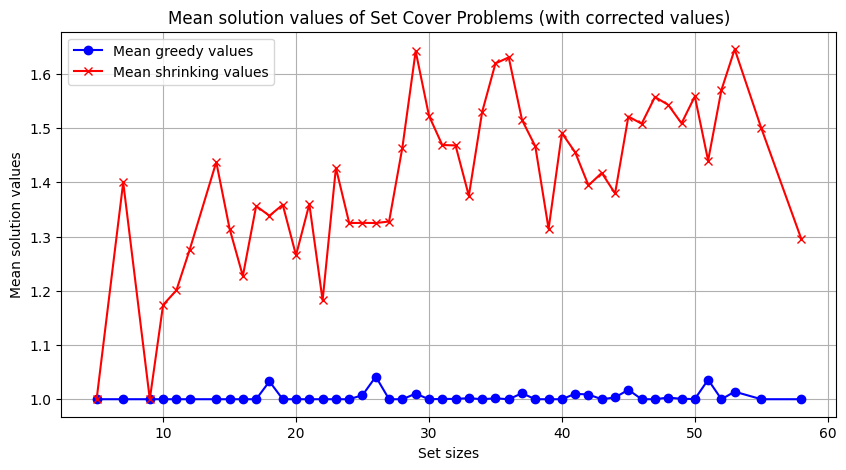

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(sorted_unique_sizes, sorted_mean_values_greedy, marker='o', linestyle='-', color='b', label='Mean greedy values')
plt.plot(sorted_unique_sizes, sorted_mean_values_shrinking, marker='x', linestyle='-', color='r', label='Mean shrinking values')


# Adding labels and title
plt.xlabel('Set sizes')
plt.ylabel('Mean solution values')
plt.title('Mean solution values of Set Cover Problems (with corrected values)')
plt.legend()

# Show the plot
plt.grid(True)
plt.show()